# Basic use of BooN
We illustrate by examples the main methods of BooN.

In [7]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import networkx as nx
from sympy.abc import w, x, y, z, v
from tabulate import tabulate
from boon import *
from boon.logic import *

## Definition of a Boolean Network
Show the Boolean network in different output formats.

In [8]:
# Define the initial Boolean network
boon = BooN({x: y, y: x & z, z: w | ~x & v | y, w: x & y | ~x & z & ~w & ~v, v: ~v & w})

In [9]:
# Get the variables
print("Variables of BooN: ", boon.variables)

Variables of BooN:  {y, z, w, v, x}


### View of the network with different output formats

In [10]:
# Show BooN with different styles.
print("- SHOW NETWORK -")
print("Logical")
print(boon)

- SHOW NETWORK -
Logical
y = x ∧ z
z = w ∨ y ∨ (v ∧ ¬x)
w = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬w ∧ ¬x)
v = w ∧ ¬v
x = y


In [11]:
print("Sympy")
boon.style = SYMPY
print(boon)

Sympy
y = x & z
z = w | y | (v & ~x)
w = (x & y) | (z & ~v & ~w & ~x)
v = w & ~v
x = y


In [12]:
print("Mathematica")
boon.style = MATHEMATICA
print(boon)

Mathematica
y = x && z
z = w || y || (v && !x)
w = (x && y) || (z && !v && !w && !x)
v = w && !v
x = y


In [13]:
# Default style is LOGICAL
boon.style = LOGICAL

## Basic Operations on variables

In [14]:
# Delete variable v.
print("- DELETE v -")
boon.delete(v)
print(boon)

- DELETE v -
w = (x ∧ y) ∨ (z ∧ ¬w ∧ ¬x)
x = y
y = x ∧ z
z = w ∨ y ∨ ¬x


In [15]:
# Rename variable w to v.
print("- RENAME w to v -")
boon.rename(w, v)
print(boon)

- RENAME w to v -
v = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


## Analysis of the Dynamics

In [16]:
# compute the stable states
print("- STABLE STATES -")
stable = boon.stable_states
print(tabulate(stable, headers='keys', tablefmt='dpsl'))

- STABLE STATES -
z     v     y     x
----  ----  ----  ----
True  True  True  True


Stability logical constraints for generating the stable states.

In [17]:
print("\nStability constraints in logic:\n", prettyform(boon.stability_constraints()))


Stability constraints in logic:
 (x ⇔ y) ∧ (y ⇔ (x ∧ z)) ∧ (z ⇔ (v ∨ y ∨ ¬x)) ∧ (v ⇔ ((x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)))


### Asynchronous model

- MODEL ASYNCHRONOUS-


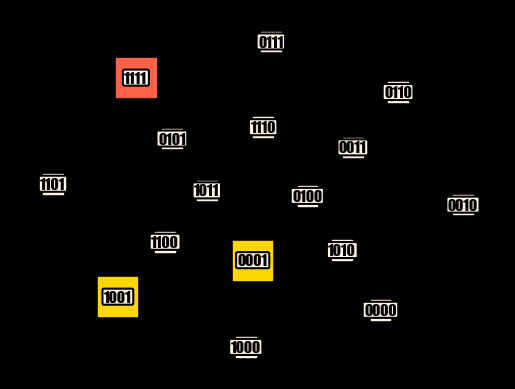

In [18]:
# initialize figures
_, ax2 = plt.subplots()
# Define the datamodel of dynamics
print("- MODEL ASYNCHRONOUS-")
M = boon.model()
ax2.axis('off')
boon.draw_model(M, pos=hypercube_layout(4), ax=ax2)

### Synchronous model

- MODEL SYNCHRONOUS-


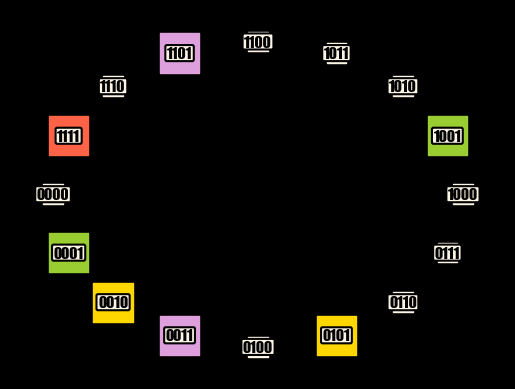

In [19]:
# Synchronous datamodel
print("- MODEL SYNCHRONOUS-")
MS = boon.model(mode=synchronous, self_loop=True)
_, ax3 = plt.subplots()
ax3.axis('off')
boon.draw_model(MS, pos=nx.shell_layout(MS), ax=ax3)

### Equilibria

#### Asynchonous

In [20]:
print("- ASYNCHRONOUS EQUILIBRIA -")
eqs = boon.equilibria(model=M)
for eq in eqs:
    print(tabulate(eq, headers='keys'))

- ASYNCHRONOUS EQUILIBRIA -
v     x     y     z
----  ----  ----  ----
True  True  True  True
v      x      y      z
-----  -----  -----  ----
False  False  False  True
True   False  False  True


#### Synchronous

In [21]:
print("- SYNCHRONOUS EQUILIBRIA -")
eqs = boon.equilibria(model=MS)
for eq in eqs:
    print(tabulate(eq, headers='keys'))

- SYNCHRONOUS EQUILIBRIA -
v     x     y     z
----  ----  ----  ----
True  True  True  True
v      x      y      z
-----  -----  -----  -----
False  False  True   False
False  True   False  True
v      x      y      z
-----  -----  -----  ----
False  False  False  True
True   False  False  True
v      x      y      z
-----  -----  -----  ----
False  False  True   True
True   True   False  True


## Interaction Graph

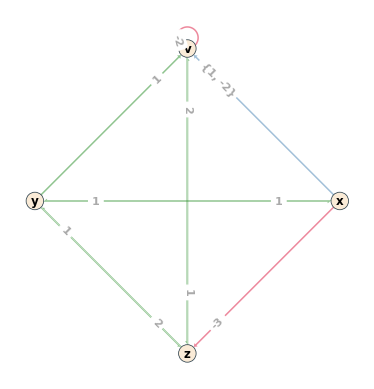

In [22]:
# Build the interaction graph
IG = boon.interaction_graph

boon.pos = nx.circular_layout(IG)
_, ax1 = plt.subplots()
ax1.axis('off')
boon.draw_IG(IG, modular=True, ax=ax1)

In [23]:
# retrieve BooN from the interaction graph
print("- FROM INTERACTION GRAPH -")
boon2= BooN.from_ig(IG)
print(boon2)

- FROM INTERACTION GRAPH -
v = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


## Load and Save

In [24]:
# save and re-load in a new BooN boon2
print("SAVE and LOAD")
boon.save("bn") 
print("BooN saved in bn.boon - next re loaded.")

boon2 = BooN.load("bn") # load is a static method of BooN
print(boon2)

SAVE and LOAD
BooN saved in bn.boon - next re loaded.
v = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


#### export and import from BoolNet file

In [25]:
print("- EXPORT & IMPORT -")
boon2.to_textfile('bn')
print("BooN exported as Bool Net format in bn.bnet - next imported. ")
boon2 = BooN.from_textfile('bn.bnet')  
print(boon2)

- EXPORT & IMPORT -
BooN exported as Bool Net format in bn.bnet - next imported. 
v = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


## Normal form Conversion
Conversion of the formulas to CNF and DNF form.

In [26]:
# Convert the formula to CNF
print("- CNF Conversion -")
boon2.cnf()
print(boon2)

- CNF Conversion -
v = (x ∨ z) ∧ (x ∨ ¬v) ∧ (y ∨ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


In [27]:
# Convert the formula do DNF
print(" - DNF conversion -")
boon2.dnf()
print(boon2)

 - DNF conversion -
v = (x ∧ y) ∨ (z ∧ ¬v ∧ ¬x)
x = y
y = x ∧ z
z = v ∨ y ∨ ¬x


## Random Graph Generation
Generate a random graph where the formulas are in DNF. The generation depends on the class of topology of the interaction graph. 3 classes are available: 'Erdos-Reny,' 'Small-World,' and 'Scale-Free.'
By default, the Erdos-Reny class is selected.
The other parameters are the number of nodes, a probability related to interaction between variables,
the probability to get a positive term, the minimal and maximal number of clauses and the prefix of the variables (default 'x').

In [28]:
# Number of nodes.
n = 20

### Erdös Reny

In [29]:
boonrand = BooN.random(n, p_link=0.25, p_pos=0.6, topology='Erdos-Reny')
boonrand.pos = nx.circular_layout(boonrand.interaction_graph)
print(boonrand)

x13 = x10
x10 = x13 ∨ ¬x1
x18 = x3
x7 = x3 ∨ x6 ∨ (x12 ∧ x13)
x1 = (x14 ∧ ¬x5) ∨ (x14 ∧ ¬x9) ∨ (x5 ∧ x8 ∧ x9)
x15 = x18 ∨ (x2 ∧ ¬x1)
x3 = x13 ∧ ¬x15
x12 = ¬x9
x11 = x6
x0 = true
x17 = true
x2 = x4 ∨ (x15 ∧ x16 ∧ ¬x1)
x14 = ¬x2 ∨ ¬x9
x6 = false
x8 = x13 ∨ ¬x14
x5 = x1 ∨ ¬x11 ∨ ¬x17 ∨ ¬x7
x16 = x14 ∨ ¬x10
x9 = x17
x19 = x18 ∨ x8
x4 = true


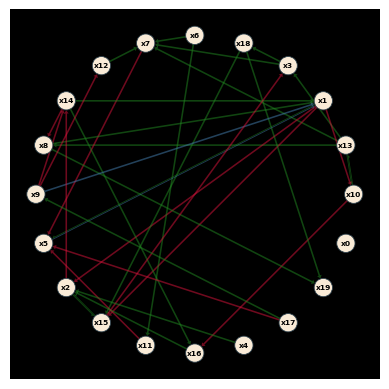

In [30]:
boonrand.draw_IG()

### Small World 

In [31]:
boonrand = BooN.random(n, p_link=0.75, p_pos=0.6, topology='Small-World')
boonrand.pos = nx.circular_layout(boonrand.interaction_graph)
print(boonrand)

x13 = x14 ∨ ¬x11
x10 = x11 ∨ x12 ∨ x13
x18 = x1 ∨ x17
x7 = x2 ∨ x9 ∨ ¬x6
x1 = true
x3 = ¬x2
x15 = x14
x12 = x14 ∨ ¬x2 ∨ (x0 ∧ x11)
x11 = x2 ∧ ¬x15
x0 = x18
x17 = true
x2 = x17 ∨ ¬x0
x14 = ¬x4
x6 = x18 ∨ x4 ∨ ¬x5
x8 = ¬x13 ∧ ¬x7
x5 = x3 ∨ x7
x16 = x10 ∨ x14 ∨ ¬x17
x19 = ¬x16
x9 = ¬x8
x4 = x7


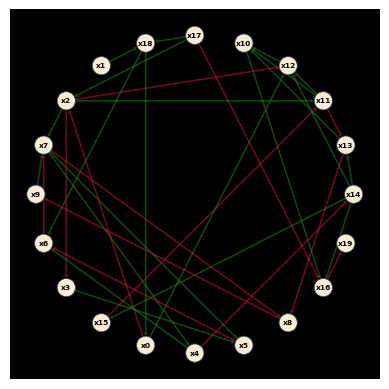

In [32]:
boonrand.draw_IG()

### Scale Free

In [33]:
boonrand = BooN.random(n, p_link=0.2, p_pos=0.5, topology='Scale-Free')
boonrand.pos = nx.circular_layout(boonrand.interaction_graph)
print(boonrand)

x13 = true
x10 = x0
x18 = true
x7 = false
x1 = ¬x15 ∧ ¬x2
x15 = false
x3 = true
x12 = ¬x0
x11 = true
x0 = x6 ∧ ¬x0 ∧ ¬x1 ∧ ¬x16 ∧ ¬x5 ∧ ¬x9
x17 = false
x2 = ¬x6 ∧ (¬x0 ∨ ¬x2)
x14 = true
x6 = x8
x8 = false
x5 = false
x16 = true
x9 = true
x19 = ¬x2
x4 = true


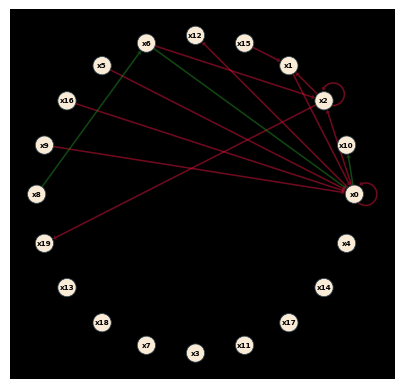

In [34]:
boonrand.draw_IG()